# Evaluación y Validación de Modelos de Agrupamiento No Supervisado
**Curso:** Machine Learning 1
**Objetivo:** Implementar, evaluar y contrastar algoritmos de *clustering* (K-Means, Jerárquico y GMM) justificando la selección de hiperparámetros mediante métricas intrínsecas, y analizar el espacio latente topológico mediante PCA y análisis de densidad.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 1. Carga, Preprocesamiento y Análisis de Colinealidad
Extraemos el espacio de características numéricas. Antes de modelar, visualizamos la matriz de correlación de Pearson para detectar multicolinealidad, lo cual justificará nuestro posterior uso de PCA. Finalmente, aplicamos estandarización ($Z-score$).

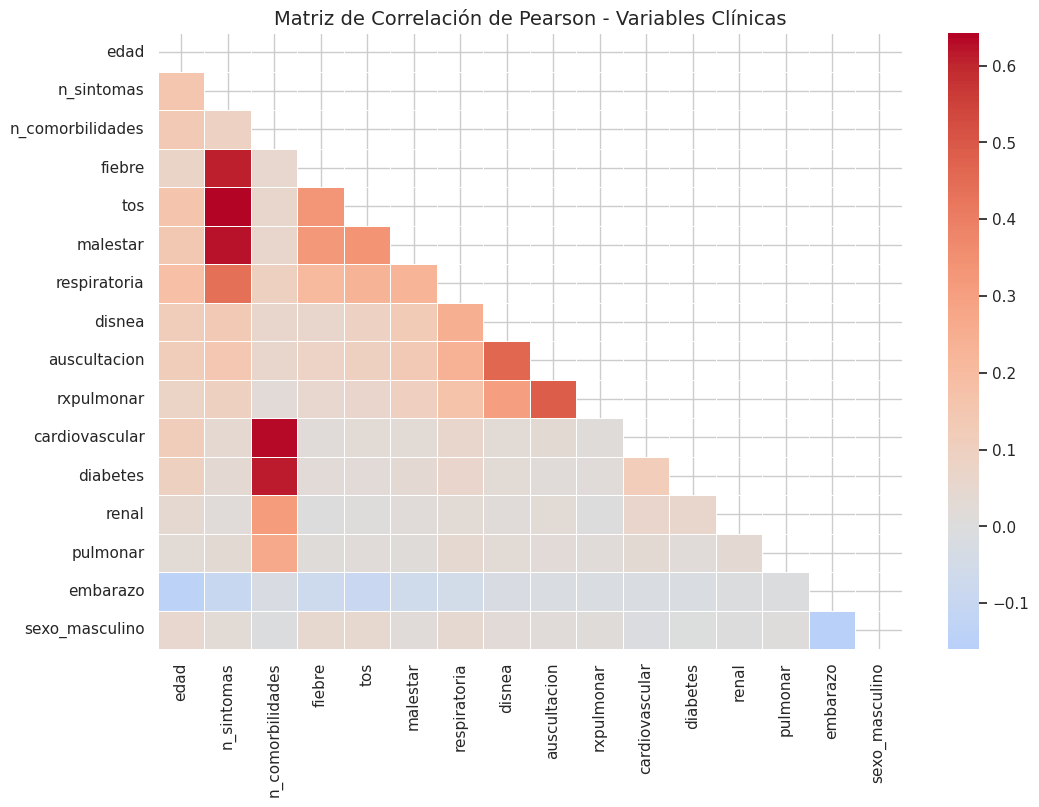

Dataset preprocesado. Dimensiones: 16 variables, 49515 registros.


In [13]:
df = pd.read_csv("dataset_no_supervisado.csv")

# Selección de espacio de características
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cols_to_drop = ['id_registro', 'desc_fallecido', 'desc_ola']
features = [col for col in numeric_cols if col not in cols_to_drop]
X = df[features]

# Matriz de Correlación (Heatmap)
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(X.corr(), dtype=bool))
sns.heatmap(X.corr(), mask=mask, cmap='coolwarm', center=0, annot=False, linewidths=.5)
plt.title('Matriz de Correlación de Pearson - Variables Clínicas', fontsize=14)
plt.show()

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Dataset preprocesado. Dimensiones: {X_scaled.shape[1]} variables, {X_scaled.shape[0]} registros.")

## 2. Optimización de Hiperparámetros ($K$) para Baseline
Evaluación del número óptimo de clústeres mediante Inercia (WCSS) y el Coeficiente de Silhouette. Utilizamos un muestreo estratificado para Silhouette debido a su complejidad computacional $O(N^2)$.

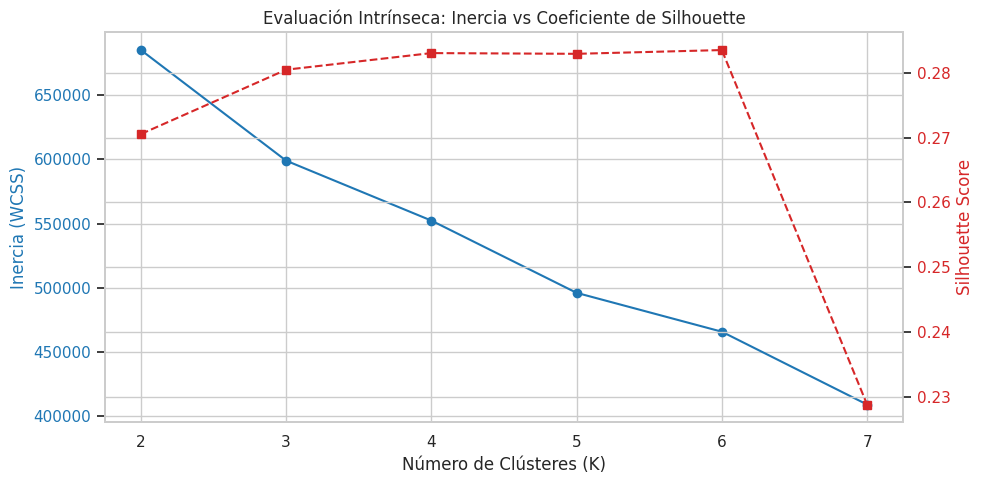

In [14]:
inercia = []
silhouette_avg = []
rango_k = range(2, 8)

np.random.seed(42)
indices_m = np.random.choice(X_scaled.shape[0], size=10000, replace=False)
X_muestra = X_scaled[indices_m]

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inercia.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(X_muestra, kmeans.predict(X_muestra)))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Inercia (WCSS)', color='tab:blue')
ax1.plot(rango_k, inercia, marker='o', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(rango_k, silhouette_avg, marker='s', linestyle='--', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Evaluación Intrínseca: Inercia vs Coeficiente de Silhouette')
fig.tight_layout()
plt.show()

## 3. Benchmarking de Algoritmos No Supervisados
Contraste métrico del modelo geométrico base (K-Means) frente a enfoques jerárquicos (Agglomerative) y probabilísticos (GMM).

In [15]:
print("Entrenando modelos de benchmarking (K=3)...")

# 1. K-Means
labels_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_muestra)
sil_kmeans = silhouette_score(X_muestra, labels_kmeans)

# 2. Agglomerative
labels_agg = AgglomerativeClustering(n_clusters=3).fit_predict(X_muestra)
sil_agg = silhouette_score(X_muestra, labels_agg)

# 3. GMM (Matrices de covarianza completas)
labels_gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42).fit_predict(X_muestra)
sil_gmm = silhouette_score(X_muestra, labels_gmm)

resultados = pd.DataFrame({
    'Modelo': ['K-Means', 'Agglomerative', 'Gaussian Mixture (GMM)'],
    'Enfoque': ['Geométrico (Centroides)', 'Jerárquico (Bottom-Up)', 'Probabilístico (Densidad)'],
    'Silhouette Score': [sil_kmeans, sil_agg, sil_gmm]
}).sort_values(by='Silhouette Score', ascending=False)

display(resultados.style.background_gradient(subset=['Silhouette Score'], cmap='Greens'))

Entrenando modelos de benchmarking (K=3)...


,Modelo,Enfoque,Silhouette Score
2,Gaussian Mixture (GMM),Probabilístico (Densidad),0.437759
0,K-Means,Geométrico (Centroides),0.280055
1,Agglomerative,Jerárquico (Bottom-Up),0.213949


## 4. Análisis de Dimensionalidad (PCA) y Semántica Latente
Evaluación de la retención de varianza y extracción de autovectores (Loadings) para interpretar qué significan clínicamente los ejes de nuestro espacio latente.

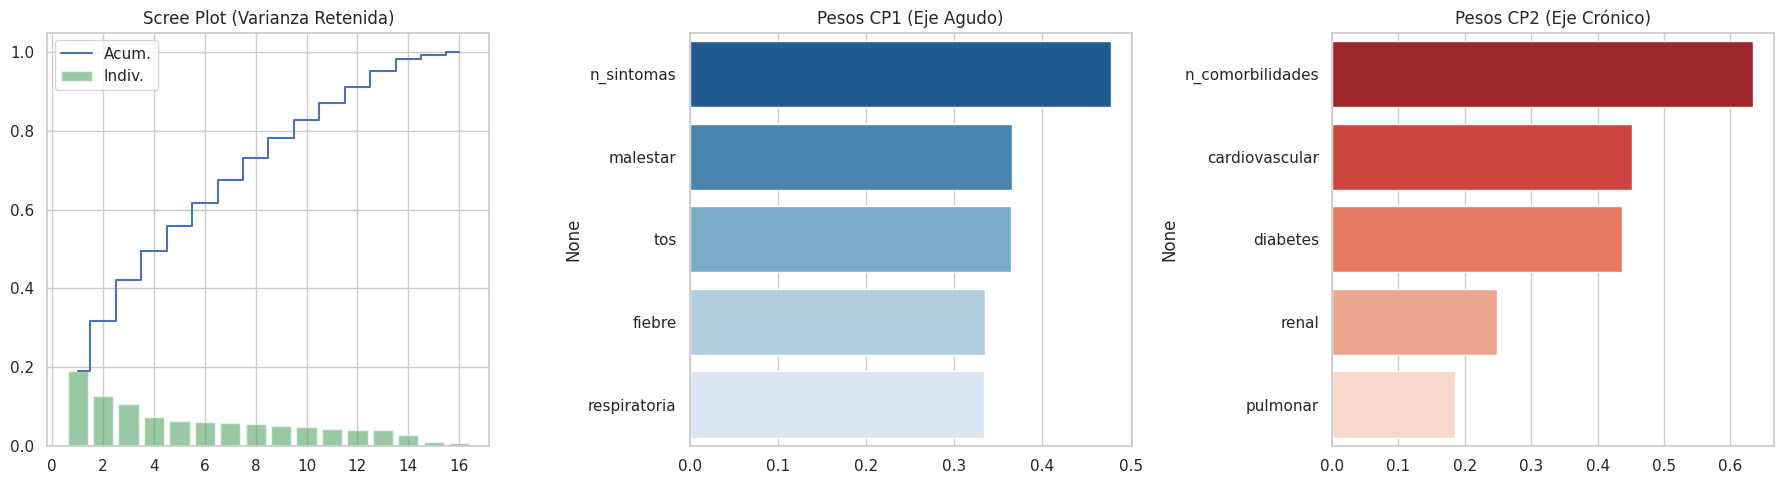

In [16]:
pca_full = PCA().fit(X_scaled)
var_exp = pca_full.explained_variance_ratio_

pca_2 = PCA(n_components=2).fit(X_scaled)
loadings = pd.DataFrame(pca_2.components_.T, columns=['CP1', 'CP2'], index=features)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scree Plot
axes[0].bar(range(1, len(var_exp)+1), var_exp, alpha=0.6, color='g', label='Indiv.')
axes[0].step(range(1, len(var_exp)+1), np.cumsum(var_exp), where='mid', color='b', label='Acum.')
axes[0].set_title('Scree Plot (Varianza Retenida)')
axes[0].legend()

# Loadings CP1
top_cp1 = loadings['CP1'].abs().sort_values(ascending=False).head(5)
sns.barplot(x=top_cp1.values, y=top_cp1.index, ax=axes[1], palette='Blues_r')
axes[1].set_title('Pesos CP1 (Eje Agudo)')

# Loadings CP2
top_cp2 = loadings['CP2'].abs().sort_values(ascending=False).head(5)
sns.barplot(x=top_cp2.values, y=top_cp2.index, ax=axes[2], palette='Reds_r')
axes[2].set_title('Pesos CP2 (Eje Crónico)')

plt.tight_layout()
plt.show()

## 5. Visualización Topológica y Análisis de Densidades (Violin Plots)
Comprobamos visualmente cómo las matrices de covarianza de GMM se adaptan al espacio PCA. Posteriormente, utilizamos gráficos de violín para observar la verdadera distribución de probabilidad subyacente de las variables clave en el modelo ganador.

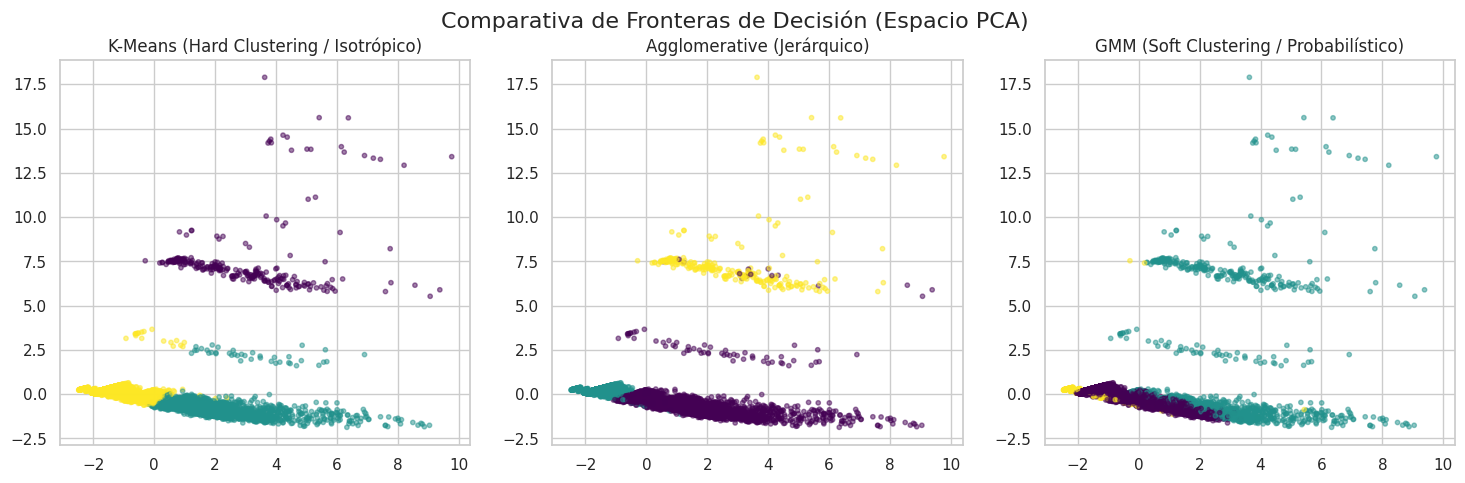

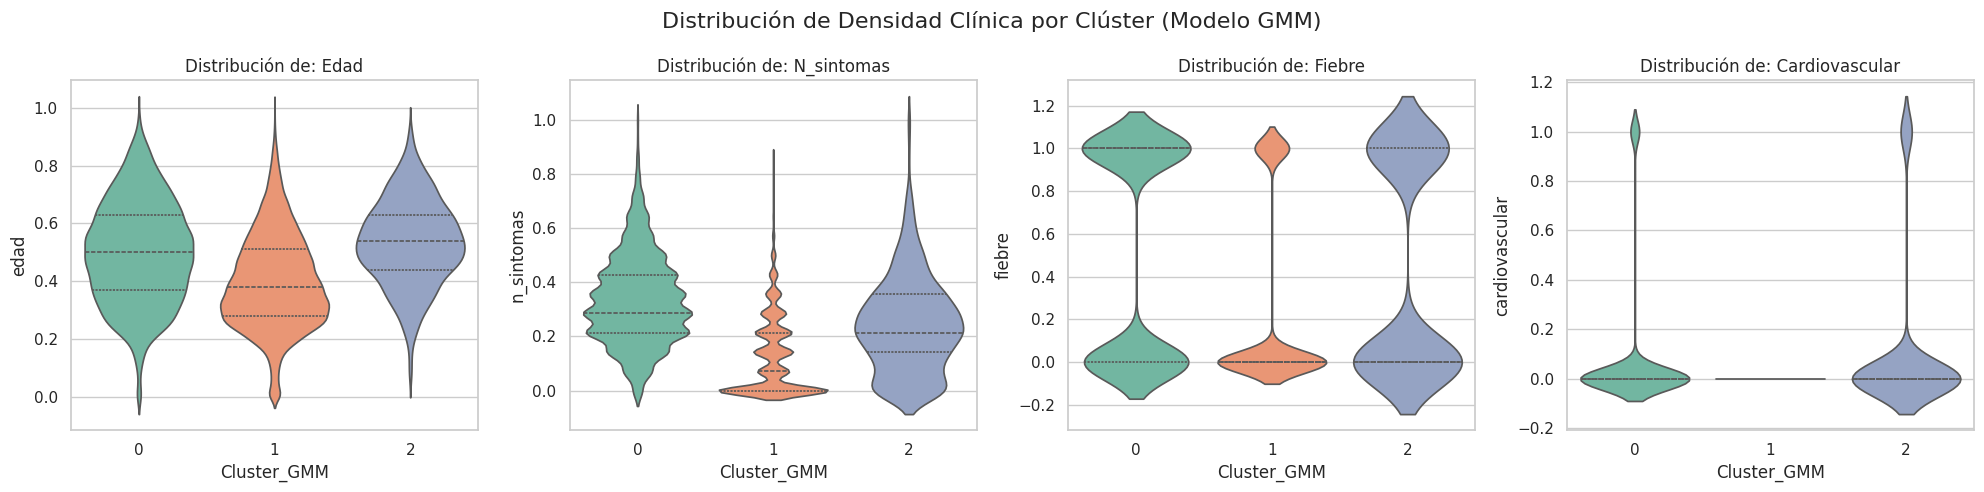

In [17]:
# Graficar fronteras de decisión en el espacio PCA
X_pca_muestra = pca_2.transform(X_muestra)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparativa de Fronteras de Decisión (Espacio PCA)', fontsize=16)

axes[0].scatter(X_pca_muestra[:, 0], X_pca_muestra[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.5, s=10)
axes[0].set_title('K-Means (Hard Clustering / Isotrópico)')

axes[1].scatter(X_pca_muestra[:, 0], X_pca_muestra[:, 1], c=labels_agg, cmap='viridis', alpha=0.5, s=10)
axes[1].set_title('Agglomerative (Jerárquico)')

axes[2].scatter(X_pca_muestra[:, 0], X_pca_muestra[:, 1], c=labels_gmm, cmap='viridis', alpha=0.5, s=10)
axes[2].set_title('GMM (Soft Clustering / Probabilístico)')
plt.show()

# Asignar etiquetas GMM al dataset original para el análisis de distribución
gmm_final = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
df['Cluster_GMM'] = gmm_final.fit_predict(X_scaled)

# Gráficos de Violín para variables clave
features_interes = ['edad', 'n_sintomas', 'fiebre', 'cardiovascular']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Distribución de Densidad Clínica por Clúster (Modelo GMM)', fontsize=16)

for i, feature in enumerate(features_interes):
    sns.violinplot(x='Cluster_GMM', y=feature, data=df, ax=axes[i], palette='Set2', inner="quartile")
    axes[i].set_title(f'Distribución de: {feature.capitalize()}')

plt.tight_layout()
plt.show()